In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer

In [2]:
data= pd.read_csv("/content/Train.csv")
data.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [3]:
data.info()

data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


,ID,Age,Work_Experience,Family_Size
count,8068.000000,8068.000000,7239.000000,7733.000000
mean,463479.214551,43.466906,2.641663,2.850123
std,2595.381232,16.711696,3.406763,1.531413
min,458982.000000,18.000000,0.000000,1.000000
25%,461240.750000,30.000000,0.000000,2.000000
50%,463472.500000,40.000000,1.000000,3.000000
75%,465744.250000,53.000000,4.000000,4.000000
max,467974.000000,89.000000,14.000000,9.000000


In [4]:
data.shape

(8068, 11)

In [5]:
data.columns

Index(['ID', 'Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession',
       'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1',
       'Segmentation'],
      dtype='object')

In [6]:
data.isnull().sum()

,0
ID,0
Gender,0
Ever_Married,140
Age,0
Graduated,78
Profession,124
Work_Experience,829
Spending_Score,0
Family_Size,335
Var_1,76


In [7]:
(data.isnull().sum()/len(data))*100

,0
ID,0.000000
Gender,0.000000
Ever_Married,1.735250
Age,0.000000
Graduated,0.966782
Profession,1.536936
Work_Experience,10.275161
Spending_Score,0.000000
Family_Size,4.152206
Var_1,0.941993


In [8]:
for col in data.columns:
  print("\n", col)
  print(data[col].unique())


 ID
[462809 462643 466315 ... 465406 467299 461879]

 Gender
['Male' 'Female']

 Ever_Married
['No' 'Yes' nan]

 Age
[22 38 67 40 56 32 33 61 55 26 19 70 58 41 31 79 49 18 36 35 45 42 83 27
 28 47 29 57 76 25 72 48 74 59 39 51 30 63 52 60 68 86 50 43 80 37 46 69
 78 71 82 23 20 85 21 53 62 75 65 89 66 73 77 87 84 81 88]

 Graduated
['No' 'Yes' nan]

 Profession
['Healthcare' 'Engineer' 'Lawyer' 'Entertainment' 'Artist' 'Executive'
 'Doctor' 'Homemaker' 'Marketing' nan]

 Work_Experience
[ 1. nan  0.  4.  9. 12.  3. 13.  5.  8. 14.  7.  2.  6. 10. 11.]

 Spending_Score
['Low' 'Average' 'High']

 Family_Size
[ 4.  3.  1.  2.  6. nan  5.  8.  7.  9.]

 Var_1
['Cat_4' 'Cat_6' 'Cat_7' 'Cat_3' 'Cat_1' 'Cat_2' nan 'Cat_5']

 Segmentation
['D' 'A' 'B' 'C']


In [9]:
data.drop("ID", axis=1, inplace=True)

In [10]:
segmentation=data["Segmentation"].copy()
data.drop("Segmentation", axis=1, inplace=True)

In [11]:
data.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4
1,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4
2,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6
3,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6
4,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6


In [12]:
data["Ever_Married"].fillna(data["Ever_Married"].mode()[0], inplace=True)
data.isnull().sum()

/tmp/ipykernel_2054/4156747301.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Ever_Married"].fillna(data["Ever_Married"].mode()[0], inplace=True)


,0
Gender,0
Ever_Married,0
Age,0
Graduated,78
Profession,124
Work_Experience,829
Spending_Score,0
Family_Size,335
Var_1,76


In [13]:
data["Graduated"].fillna(data["Graduated"].mode()[0], inplace=True)
data.isnull().sum()

/tmp/ipykernel_2054/74155956.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Graduated"].fillna(data["Graduated"].mode()[0], inplace=True)


,0
Gender,0
Ever_Married,0
Age,0
Graduated,0
Profession,124
Work_Experience,829
Spending_Score,0
Family_Size,335
Var_1,76


In [14]:
data["Profession"].fillna(data["Profession"].mode()[0], inplace=True)
data.isnull().sum()

/tmp/ipykernel_2054/2776622685.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Profession"].fillna(data["Profession"].mode()[0], inplace=True)


,0
Gender,0
Ever_Married,0
Age,0
Graduated,0
Profession,0
Work_Experience,829
Spending_Score,0
Family_Size,335
Var_1,76


In [15]:
data["Work_Experience"] = data["Work_Experience"].fillna(
    data["Work_Experience"].median())

data["Family_Size"] = data["Family_Size"].fillna(
    data["Family_Size"].median())

data["Var_1"] = data["Var_1"].fillna(
    data["Var_1"].mode()[0]
)

In [16]:
data.isnull().sum()

,0
Gender,0
Ever_Married,0
Age,0
Graduated,0
Profession,0
Work_Experience,0
Spending_Score,0
Family_Size,0
Var_1,0


In [17]:
data.duplicated().sum()

np.int64(947)

In [18]:
data.drop_duplicates(inplace=True)

In [19]:
data.shape

(7121, 9)

In [20]:
num_cols=["Age","Work_Experience", "Family_Size"]
cat_cols=["Gender","Ever_Married","Graduated","Profession","Spending_Score","Var_1"]

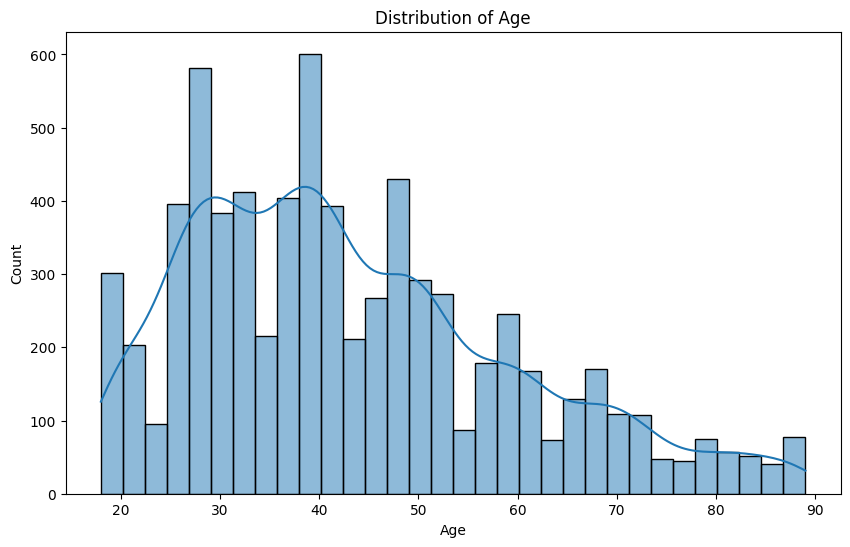

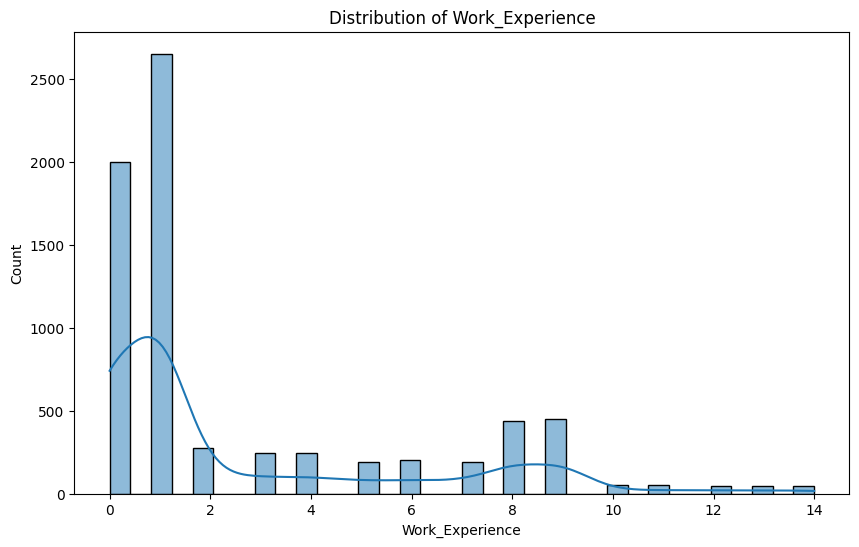

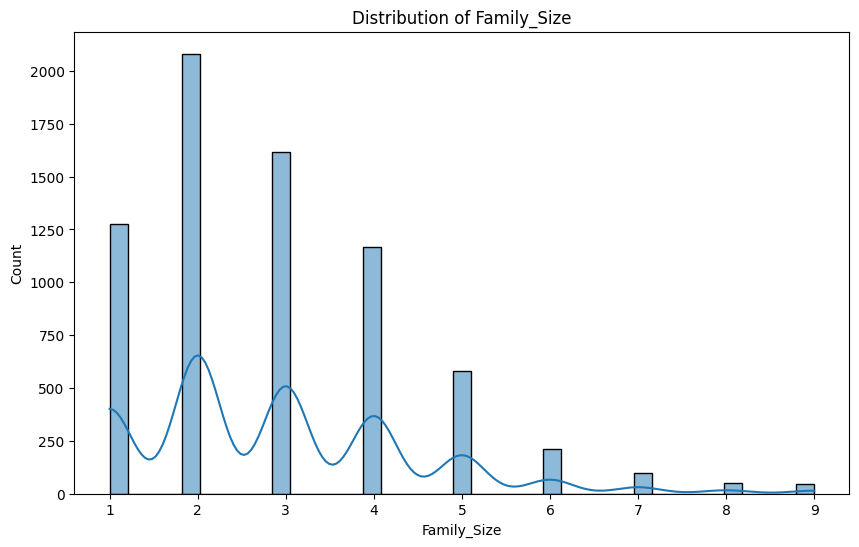

In [21]:
for col in num_cols:
  plt.figure(figsize=(10,6))
  sns.histplot(data[col], kde=True)
  plt.title(f"Distribution of {col}")
  plt.show()

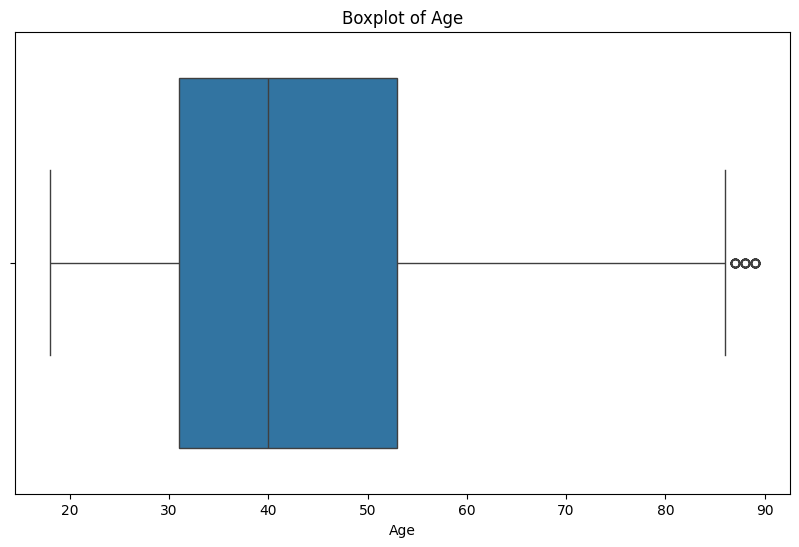

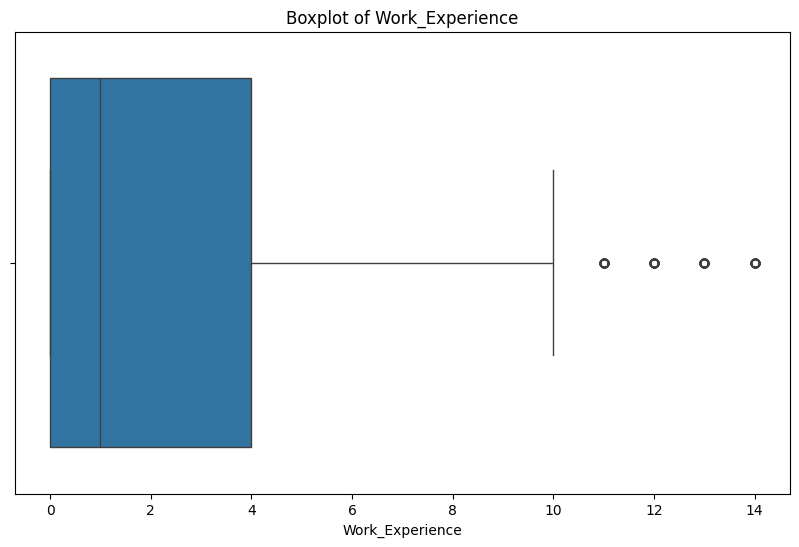

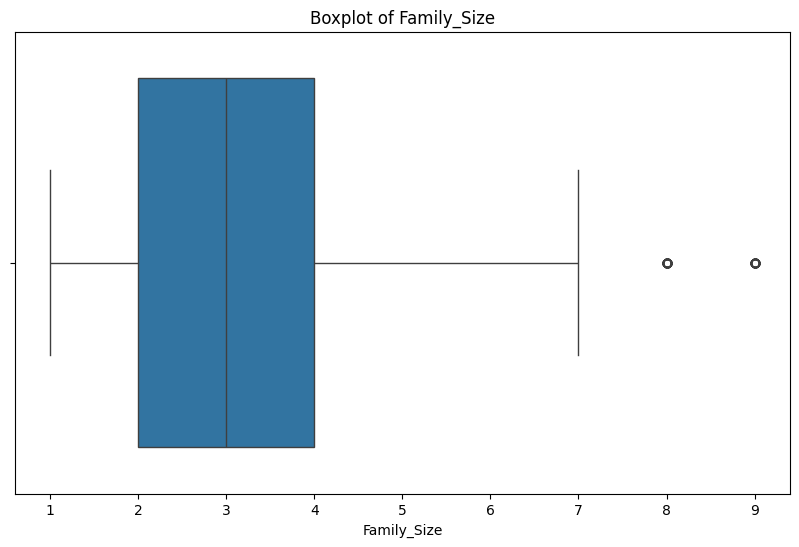

In [22]:
for col in num_cols:
  plt.figure(figsize=(10,6))
  sns.boxplot(x=data[col])
  plt.title(f"Boxplot of {col}")
  plt.show()

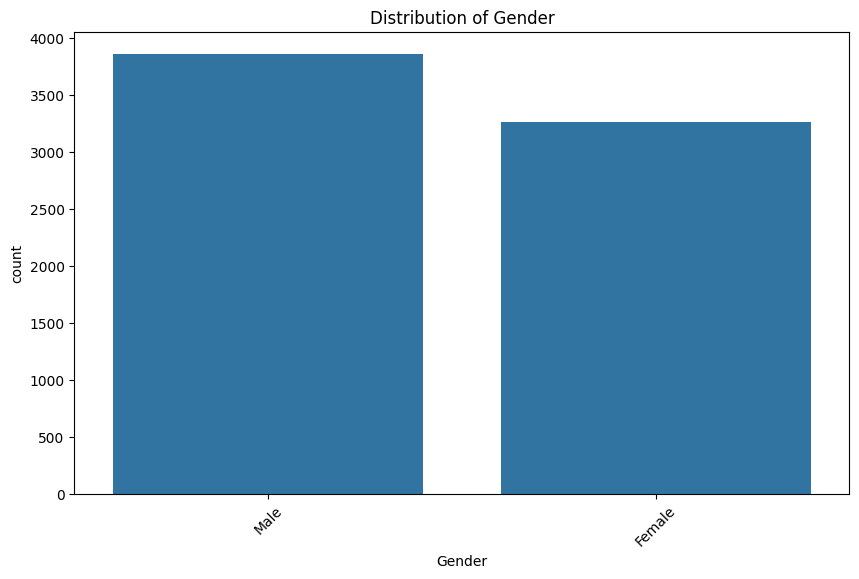

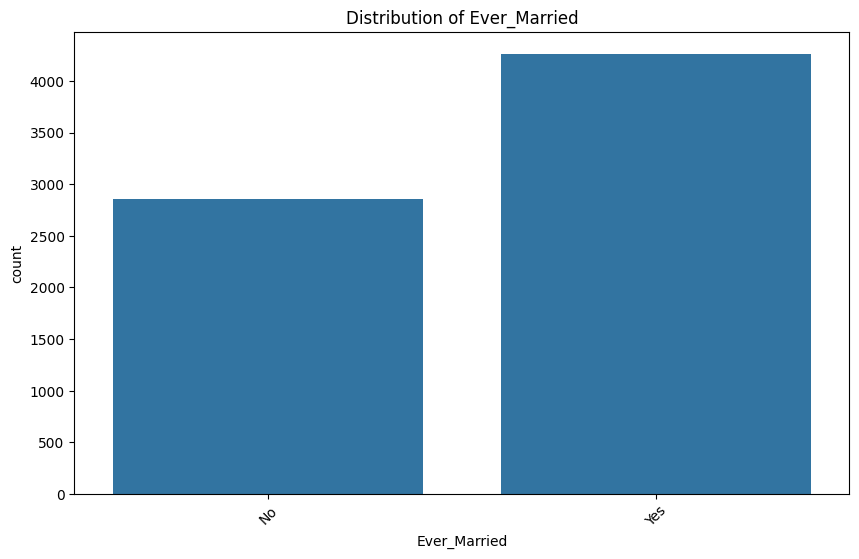

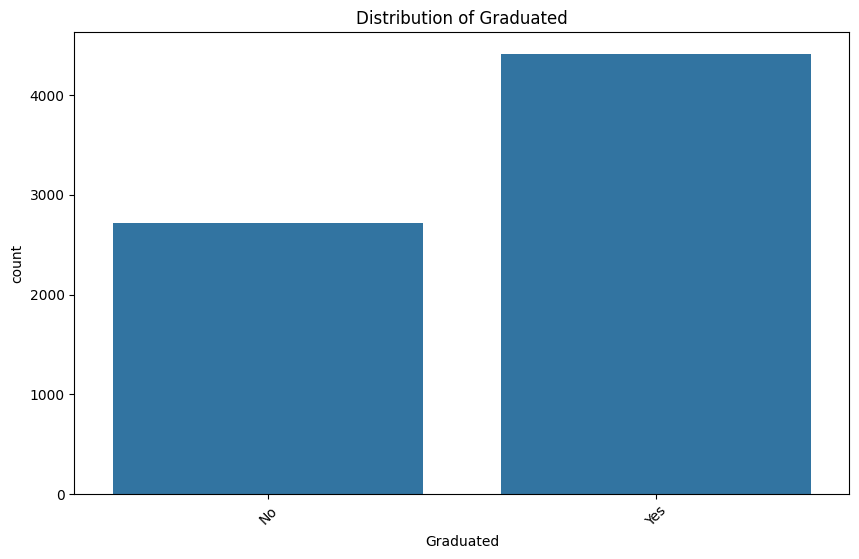

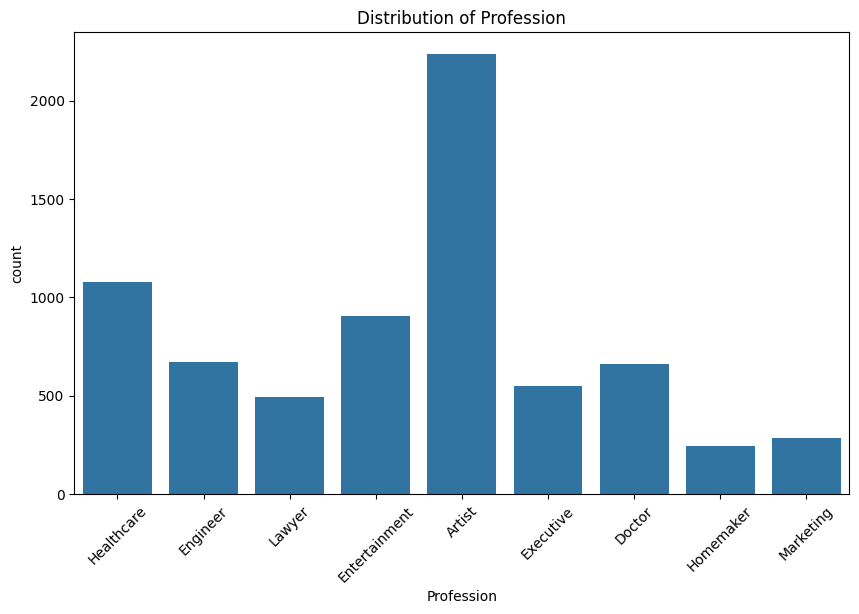

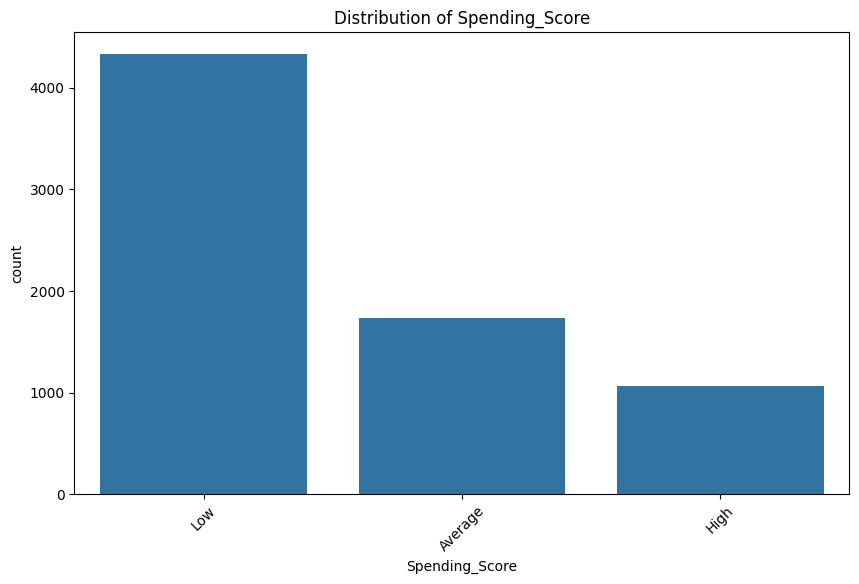

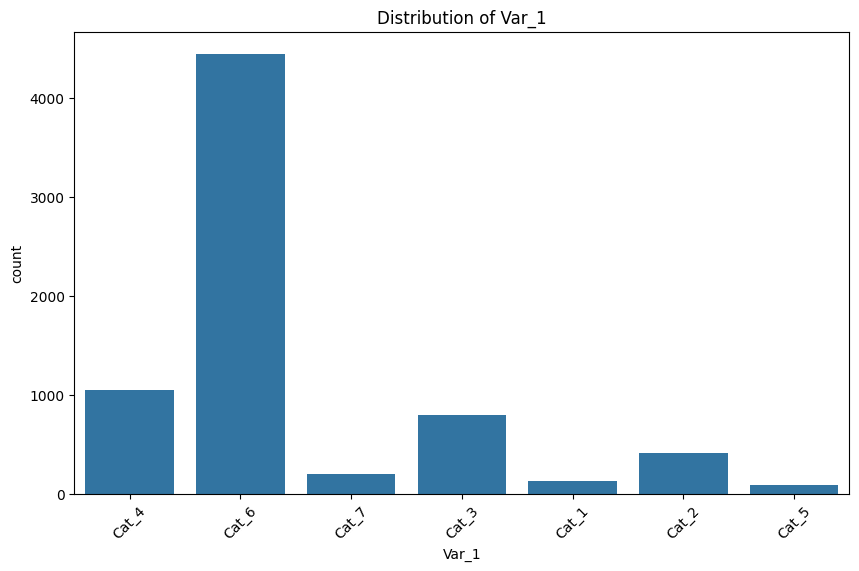

In [23]:
for col in cat_cols:
  plt.figure(figsize=(10,6))
  sns.countplot(data=data, x=col)
  plt.title(f"Distribution of {col}")
  plt.xticks(rotation=45)
  plt.show()

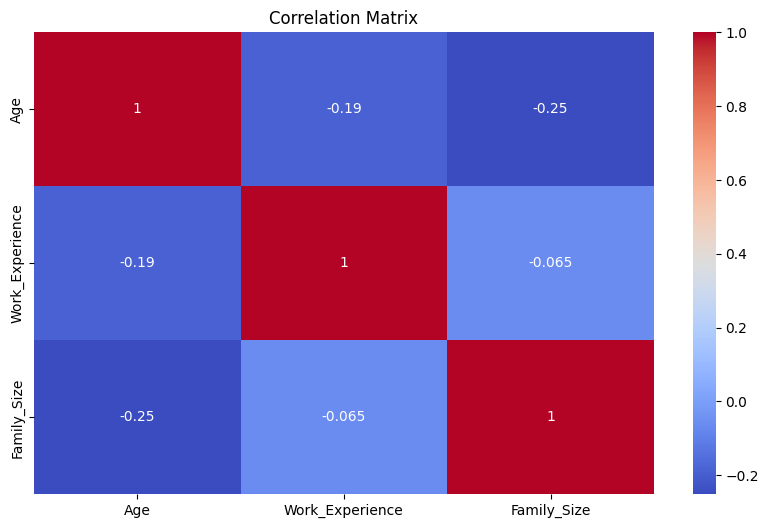

In [24]:
plt.figure(figsize=(10,6))
sns.heatmap(
    data[num_cols].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

In [25]:
encoder=OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

In [26]:
encoded_data=encoder.fit_transform(data[cat_cols])

In [27]:
encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(cat_cols),
    index=data.index
)

In [28]:
encoded_df.head(10)

,Gender_Female,Gender_Male,Ever_Married_No,Ever_Married_Yes,Graduated_No,Graduated_Yes,Profession_Artist,Profession_Doctor,Profession_Engineer,Profession_Entertainment,...,Spending_Score_Average,Spending_Score_High,Spending_Score_Low,Var_1_Cat_1,Var_1_Cat_2,Var_1_Cat_3,Var_1_Cat_4,Var_1_Cat_5,Var_1_Cat_6,Var_1_Cat_7
0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [29]:
scalar=StandardScaler()

In [30]:
scaled_num= scalar.fit_transform(data[num_cols])

In [31]:
scaled_df = pd.DataFrame(
    scaled_num,
    columns=num_cols,
    index=data.index
)

In [32]:
scaled_df.head(10)

,Age,Work_Experience,Family_Size
0,-1.307700,-0.487483,0.721944
1,-0.327269,-0.487483,0.071436
2,1.449762,-0.487483,-1.229580
3,1.449762,-0.784842,-0.579072
4,-0.204715,-0.487483,2.022960
5,0.775716,-0.784842,-0.579072
6,-0.694931,-0.487483,0.071436
7,-0.633654,-0.487483,0.071436
8,1.082100,-0.784842,0.071436
9,0.714439,-0.487483,0.721944


In [33]:
X= pd.concat(
    [scaled_df, encoded_df],
    axis=1
)

In [34]:
X.head(10)

,Age,Work_Experience,Family_Size,Gender_Female,Gender_Male,Ever_Married_No,Ever_Married_Yes,Graduated_No,Graduated_Yes,Profession_Artist,...,Spending_Score_Average,Spending_Score_High,Spending_Score_Low,Var_1_Cat_1,Var_1_Cat_2,Var_1_Cat_3,Var_1_Cat_4,Var_1_Cat_5,Var_1_Cat_6,Var_1_Cat_7
0,-1.307700,-0.487483,0.721944,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-0.327269,-0.487483,0.071436,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.449762,-0.487483,-1.229580,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.449762,-0.784842,-0.579072,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.204715,-0.487483,2.022960,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5,0.775716,-0.784842,-0.579072,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6,-0.694931,-0.487483,0.071436,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7,-0.633654,-0.487483,0.071436,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8,1.082100,-0.784842,0.071436,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9,0.714439,-0.487483,0.721944,1.0,0.0,0.0,1.0,0.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [35]:
X.shape

(7121, 28)

In [36]:
inertia=[]

for k in range(2,11):
  kmeans=KMeans(
      n_clusters= k,
      random_state=42,
      n_init=10
  )
  kmeans.fit(X)
  inertia.append(kmeans.inertia_)

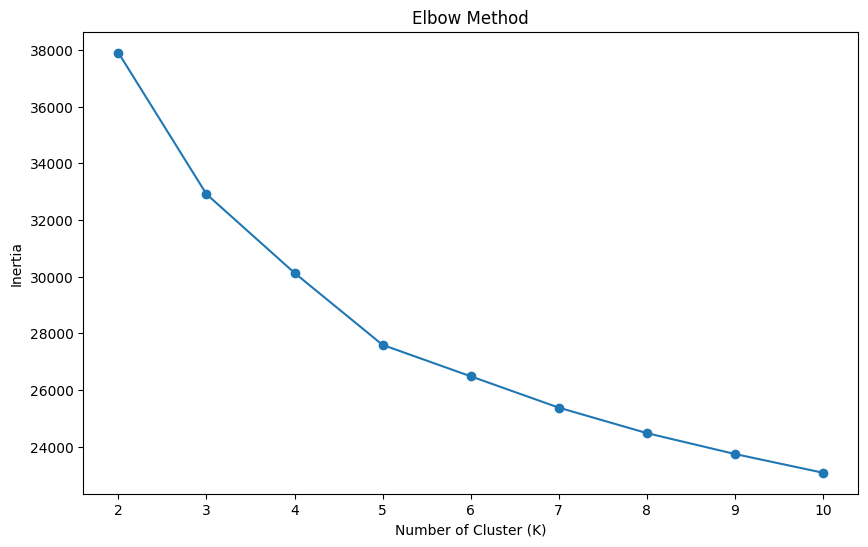

In [37]:
plt.figure(figsize=(10,6))

plt.plot(
    range(2,11),
    inertia,
    marker="o"
)
plt.xlabel("Number of Cluster (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [38]:
silhouette_scores =[]
for k in range(2,11):
  kmeans=KMeans(
      n_clusters=k,
      random_state=42,
      n_init=10
  )
  labels=kmeans.fit_predict(X)
  score=silhouette_score(X, labels)
  silhouette_scores.append(score)

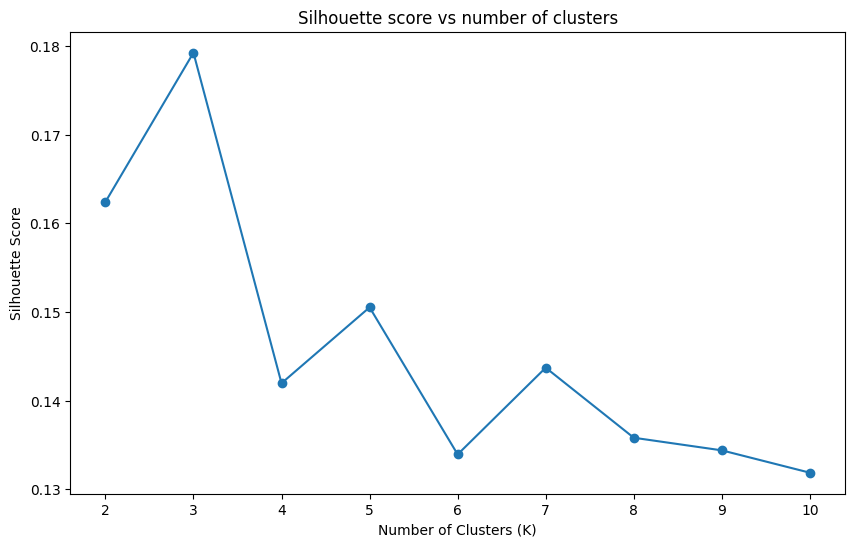

In [39]:
plt.figure(figsize=(10,6))
plt.plot(
    range(2,11),
    silhouette_scores,
    marker="o"
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette score vs number of clusters")
plt.show()

In [40]:
kmeans=KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)
clusters = kmeans.fit_predict(X)

In [41]:
data["cluster"]=clusters

In [42]:
data.head(10)

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,cluster
0,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,2
1,Female,Yes,38,Yes,Engineer,1.0,Average,3.0,Cat_4,0
2,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,0
3,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,0
4,Female,Yes,40,Yes,Entertainment,1.0,High,6.0,Cat_6,0
5,Male,Yes,56,No,Artist,0.0,Average,2.0,Cat_6,0
6,Male,No,32,Yes,Healthcare,1.0,Low,3.0,Cat_6,2
7,Female,No,33,Yes,Healthcare,1.0,Low,3.0,Cat_6,2
8,Female,Yes,61,Yes,Engineer,0.0,Low,3.0,Cat_7,0
9,Female,Yes,55,Yes,Artist,1.0,Average,4.0,Cat_6,0


In [43]:
data["cluster"].value_counts().sort_index()

,count
cluster,
0,3361
1,1557
2,2203


In [44]:
data["cluster"].value_counts(normalize=True)*100

,proportion
cluster,
0,47.198427
2,30.936666
1,21.864907


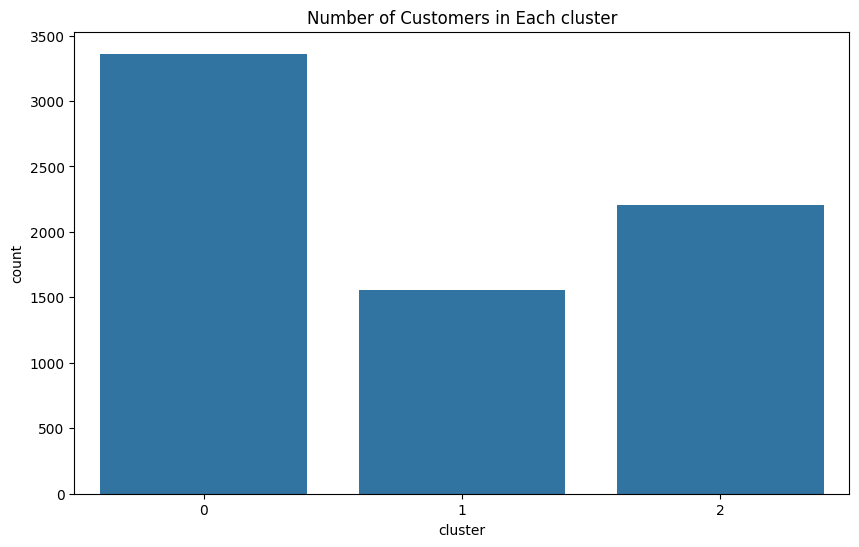

In [45]:
plt.figure(figsize=(10,6))
sns.countplot(
    data=data,
    x="cluster"
)
plt.title("Number of Customers in Each cluster")
plt.show()

In [46]:
cluster_summary = data.groupby("cluster")[num_cols].mean()
cluster_summary

,Age,Work_Experience,Family_Size
cluster,,,
0,55.010711,0.994942,2.597739
1,37.722543,8.258189,2.511240
2,29.507490,1.177031,3.604176


In [47]:
pd.crosstab(
    data["cluster"],
    data["Spending_Score"],
    normalize="index"
) *100

Spending_Score,Average,High,Low
cluster,,,
0,37.964891,24.337995,37.697114
1,22.479127,10.918433,66.602441
2,4.766228,3.313663,91.920109


In [48]:
pd.crosstab(
    data["cluster"],
    data["Gender"],
    normalize="index"
) *100

Gender,Female,Male
cluster,,
0,40.731925,59.268075
1,51.830443,48.169557
2,49.341807,50.658193


In [49]:
pd.crosstab(
    data["cluster"],
    data["Profession"],
    normalize="index"
) *100

Profession,Artist,Doctor,Engineer,Entertainment,Executive,Healthcare,Homemaker,Lawyer,Marketing
cluster,,,,,,,,,
0,41.267480,6.605177,8.598631,13.061589,10.978875,1.814936,1.755430,13.864921,2.052960
1,34.296724,9.120103,9.312781,13.359024,6.294155,13.680154,8.798972,1.412974,3.725112
2,14.344076,13.481616,10.758057,11.802088,3.722197,36.404902,2.088062,0.226963,7.172038


In [50]:
pd.crosstab(
    data["cluster"],
    data["Graduated"],
    normalize="index"
) *100

Graduated,No,Yes
cluster,,
0,25.438857,74.561143
1,31.342325,68.657675
2,62.187926,37.812074


In [51]:
pd.crosstab(
    data["cluster"],
    data["Var_1"],
    normalize="index"
) *100

Var_1,Cat_1,Cat_2,Cat_3,Cat_4,Cat_5,Cat_6,Cat_7
cluster,,,,,,,
0,1.666171,4.076168,10.086284,11.216900,0.862838,69.503124,2.588515
1,1.220295,5.266538,10.211946,10.789981,1.027617,69.171484,2.312139
2,2.496596,8.669995,13.527009,23.014072,1.770313,46.890604,3.631412


In [52]:
pd.crosstab(
    data["cluster"],
    data["Ever_Married"],
    normalize="index"
) *100

Ever_Married,No,Yes
cluster,,
0,8.806903,91.193097
1,47.334618,52.665382
2,82.977758,17.022242


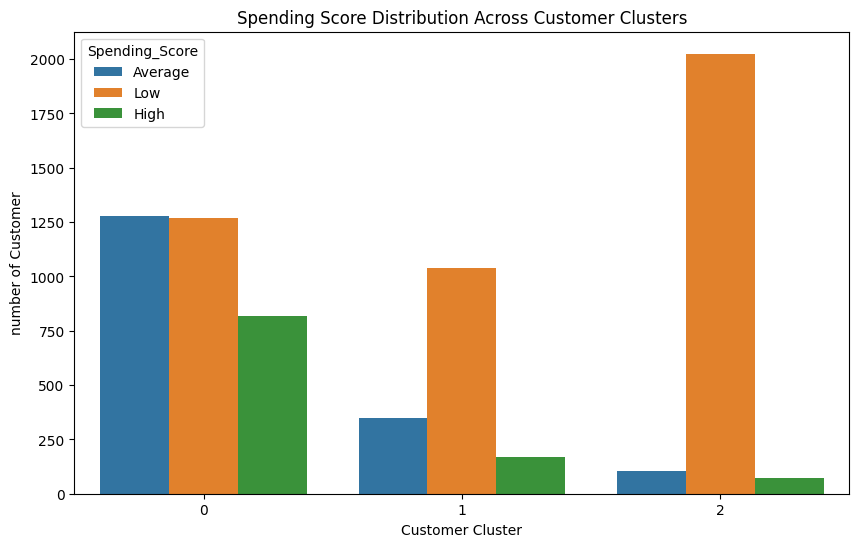

In [53]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=data,
    x="cluster",
    hue="Spending_Score"
)
plt.title("Spending Score Distribution Across Customer Clusters")
plt.xlabel("Customer Cluster")
plt.ylabel("number of Customer")

plt.show()

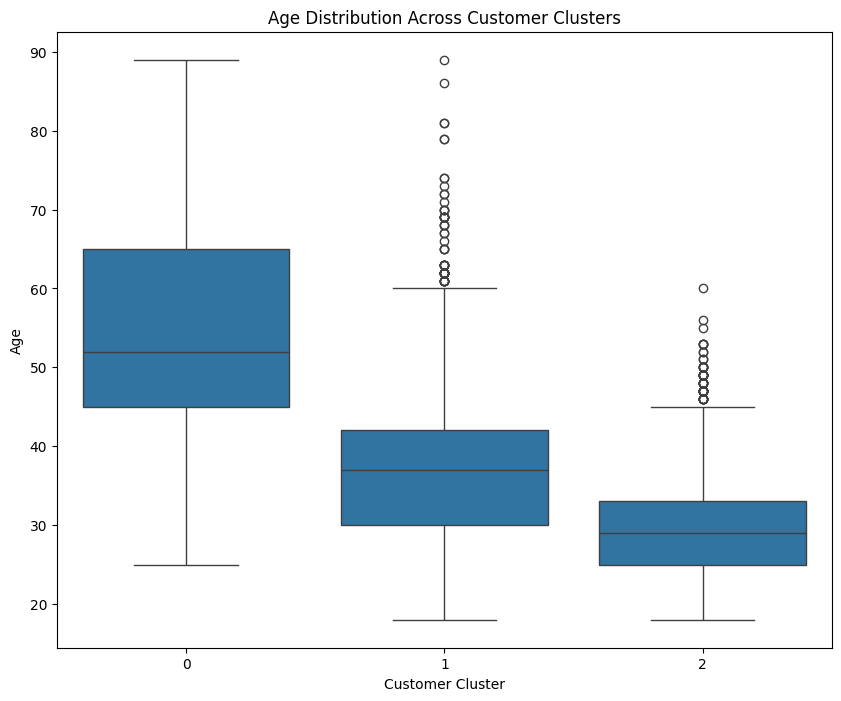

In [54]:
plt.figure(figsize=(10,8))
sns.boxplot(
    data=data,
    x="cluster",
    y="Age"
)
plt.title("Age Distribution Across Customer Clusters")
plt.xlabel("Customer Cluster")
plt.ylabel("Age")

plt.show()

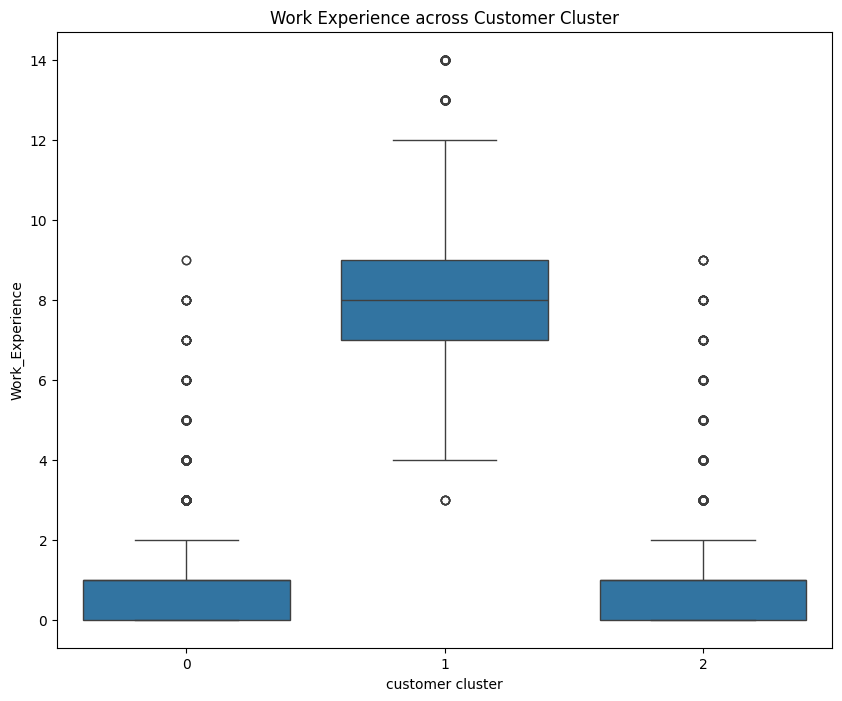

In [55]:
plt.figure(figsize=(10,8))
sns.boxplot(
    data=data,
    x="cluster",
    y="Work_Experience"
)
plt.title("Work Experience across Customer Cluster")
plt.xlabel("customer cluster")
plt.ylabel("Work_Experience")
plt.show()

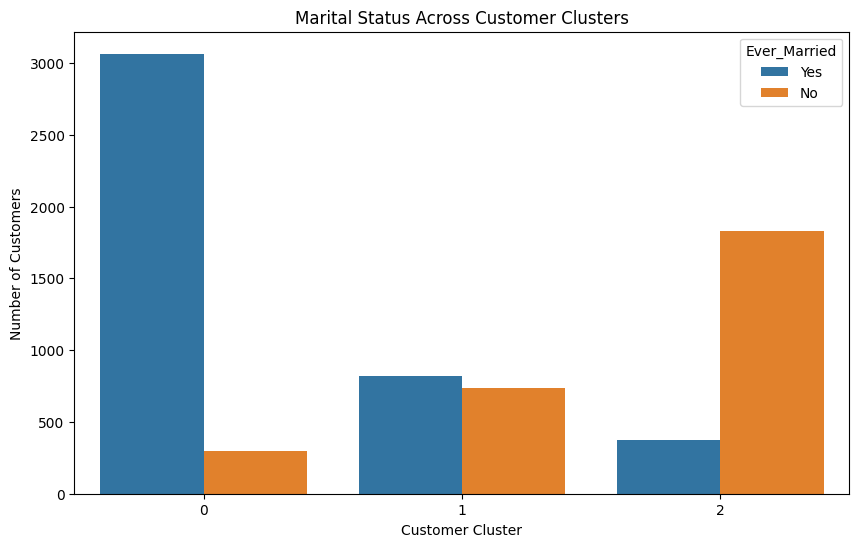

In [56]:
plt.figure(figsize=(10,6))
sns.countplot(
  data=data,
  x="cluster",
  hue="Ever_Married"
)
plt.title("Marital Status Across Customer Clusters")
plt.xlabel("Customer Cluster")
plt.ylabel("Number of Customers")

plt.show()

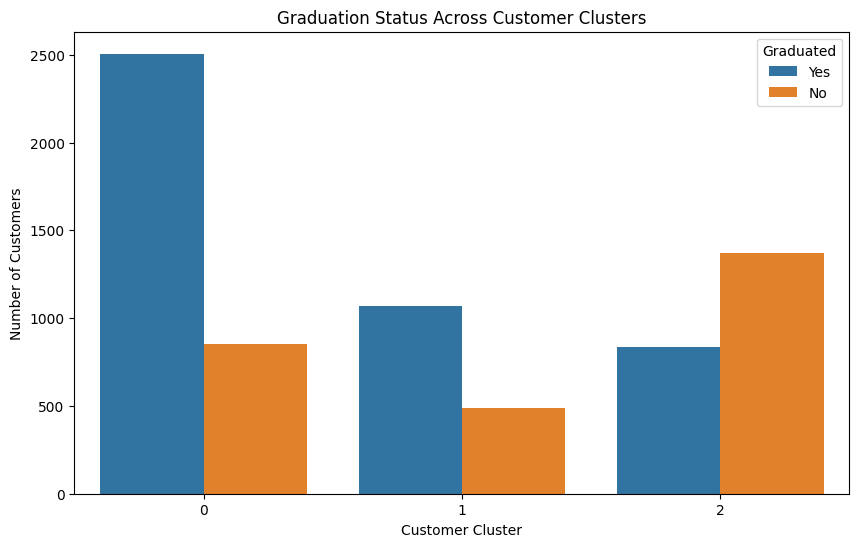

In [57]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=data,
    x="cluster",
    hue="Graduated"
)

plt.title("Graduation Status Across Customer Clusters")
plt.xlabel("Customer Cluster")
plt.ylabel("Number of Customers")

plt.show()

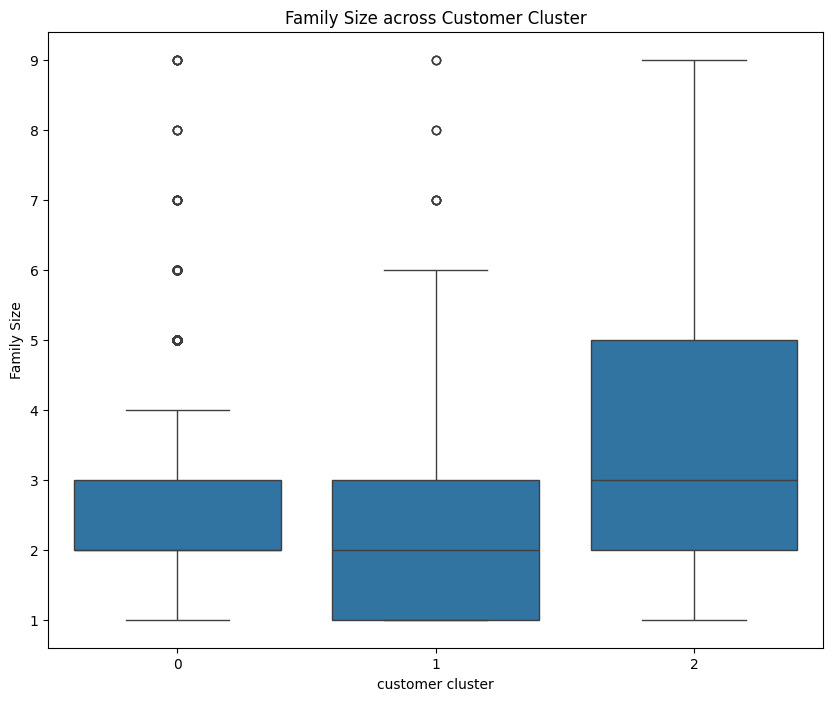

In [58]:
plt.figure(figsize=(10,8))
sns.boxplot(
    data=data,
    x="cluster",
    y="Family_Size"
)
plt.title("Family Size across Customer Cluster")
plt.xlabel("customer cluster")
plt.ylabel("Family Size")
plt.show()

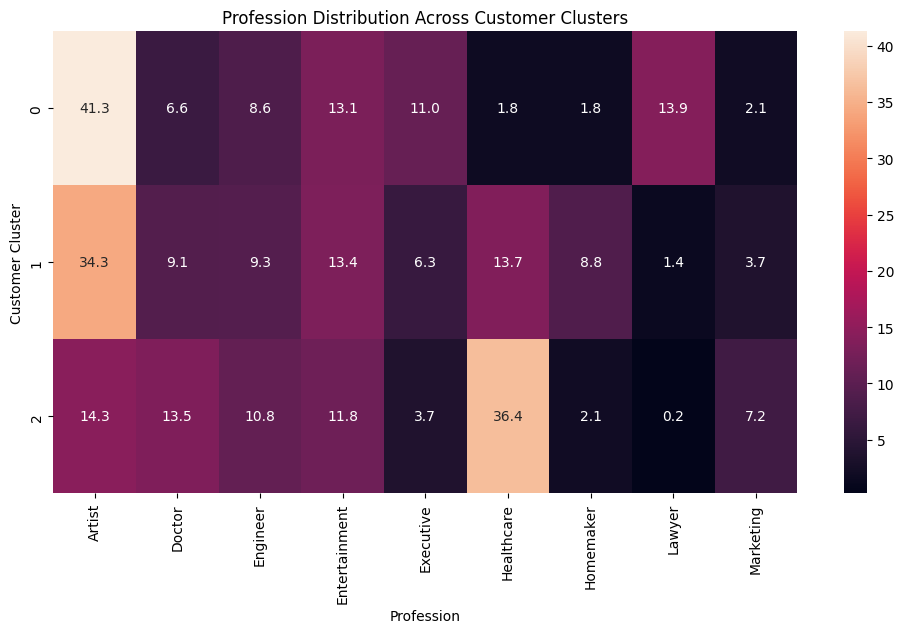

In [59]:
profession_cluster = pd.crosstab(
    data["cluster"],
    data["Profession"],
    normalize="index"
) * 100

plt.figure(figsize=(12,6))

sns.heatmap(
    profession_cluster,
    annot=True,
    fmt=".1f"
)

plt.title("Profession Distribution Across Customer Clusters")
plt.xlabel("Profession")
plt.ylabel("Customer Cluster")

plt.show()

In [60]:
cluster_num= data.groupby("cluster")[num_cols].agg(["mean","median"])
cluster_num

Age        Work_Experience        Family_Size       
              mean median            mean median        mean median
cluster                                                            
0        55.010711   52.0        0.994942    1.0    2.597739    2.0
1        37.722543   37.0        8.258189    8.0    2.511240    2.0
2        29.507490   29.0        1.177031    1.0    3.604176    3.0

In [67]:
def cluster_cat_percentage(column):
  return pd.crosstab(
      data["cluster"],
      data[column],
      normalize="index"
  ).round(3)*100

In [68]:
cluster_cat_percentage("Spending_Score")

Spending_Score,Average,High,Low
cluster,,,
0,38.0,24.3,37.7
1,22.5,10.9,66.6
2,4.8,3.3,91.9


In [69]:
cluster_cat_percentage("Gender")

Gender,Female,Male
cluster,,
0,40.7,59.3
1,51.8,48.2
2,49.3,50.7


In [70]:
cluster_cat_percentage("Profession")

Profession,Artist,Doctor,Engineer,Entertainment,Executive,Healthcare,Homemaker,Lawyer,Marketing
cluster,,,,,,,,,
0,41.3,6.6,8.6,13.1,11.0,1.8,1.8,13.9,2.1
1,34.3,9.1,9.3,13.4,6.3,13.7,8.8,1.4,3.7
2,14.3,13.5,10.8,11.8,3.7,36.4,2.1,0.2,7.2


In [71]:
cluster_cat_percentage("Ever_Married")

Ever_Married,No,Yes
cluster,,
0,8.8,91.2
1,47.3,52.7
2,83.0,17.0


In [72]:
cluster_cat_percentage("Graduated")

Graduated,No,Yes
cluster,,
0,25.4,74.6
1,31.3,68.7
2,62.2,37.8


In [74]:
data.groupby("cluster")["Work_Experience"].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,3361.0,0.994942,1.230916,0.0,0.0,1.0,1.0,9.0
1,1557.0,8.258189,2.138851,3.0,7.0,8.0,9.0,14.0
2,2203.0,1.177031,1.561480,0.0,0.0,1.0,1.0,9.0


In [75]:
pca = PCA(n_components=2)
X_pca=pca.fit_transform(X)

In [76]:
print("Explained variance ration:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance ration: [0.24430686 0.17465697]
Total explained variance: 0.4189638327125118


In [77]:
pca_data = pd.DataFrame(
    X_pca,
    columns=["PC1","PC2"]
)
pca_data["cluster"]= data["cluster"].values

In [78]:
pca_data.head(10)

,PC1,PC2,cluster
0,-1.908473,-0.879958,2
1,0.163770,-0.517963,0
2,1.857295,0.528194,0
3,2.097244,-0.413462,0
4,-0.341149,-1.604432,0
5,1.312769,-0.529083,0
6,-0.782516,-0.133013,2
7,-0.801542,0.001625,2
8,1.041191,-0.584848,0
9,0.898117,-0.793133,0


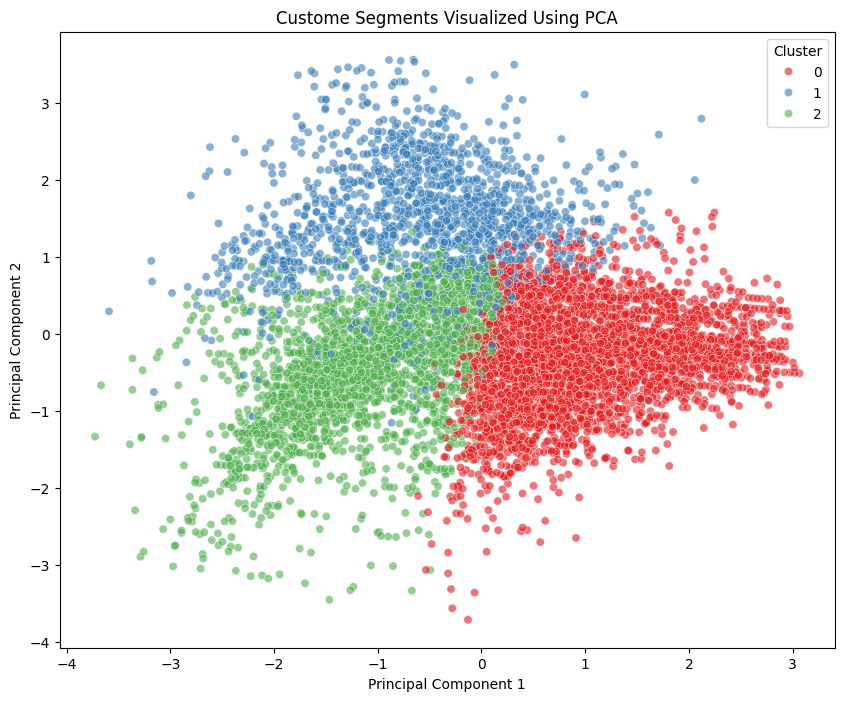

In [79]:
plt.figure(figsize=(10,8))
sns.scatterplot(
    data=pca_data,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set1",
    alpha=0.6

)
plt.title("Custome Segments Visualized Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()